# 06 - Advanced RAG Pipeline (Qdrant + Graph-aware retrieval)

Notebook advanced-only per pipeline RAG incrementale rispetto al naive:
- query rewriting/decomposition opzionale
- multi-retrieval + metadata filtering ibrido
- graph-aware expansion
- reranking deterministico
- benchmark MCQ + no-hint/judge con output metriche compatibili

## 1) Setup ambiente e import

Bootstrap del repository, import runtime advanced e utility benchmark condivise.

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from typing import Any
from dataclasses import asdict

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

def _find_repo_root_for_bootstrap(start: Path) -> Path:
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'notebooks' / 'pipelines' / 'common' / 'bootstrap.py').exists() and (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Project root non trovato. Avvia il notebook dentro il repository.')

_BOOTSTRAP_ROOT = _find_repo_root_for_bootstrap(Path.cwd().resolve())
if str(_BOOTSTRAP_ROOT) not in sys.path:
    sys.path.insert(0, str(_BOOTSTRAP_ROOT))

from notebooks.pipelines.common.bootstrap import bootstrap_notebook
ROOT, SRC = bootstrap_notebook(start=Path.cwd().resolve())

from legal_indexing.rag_runtime import (
    AdvancedAnswerGuardConfig,
    AdvancedGraphExpansionConfig,
    AdvancedHybridConfig,
    AdvancedMetadataFilteringConfig,
    AdvancedMultiRetrievalConfig,
    AdvancedRagConfig,
    AdvancedRerankConfig,
    AdvancedRewriteConfig,
    McqAnswer,
    RagRuntimeConfig,
    align_record,
    build_naive_vs_advanced_comparison,
    build_rag_graph,
    load_valid_rows,
    level_sort_key,
    persist_benchmark_artifacts,
    persist_naive_vs_advanced_comparison,
    prepare_runtime,
    resolve_eval_positions,
    resolve_ollama_chat_url,
    run_advanced_benchmark,
    run_rag_question,
)

print('ROOT:', ROOT)
print('SRC:', SRC)


ROOT: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite
SRC: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/src


## 2) Configurazione runtime advanced e benchmark

Definiamo toggle mini/full benchmark e configurazione advanced modulare.

In [2]:
DATASET_DIR = ROOT / 'data' / 'laws_dataset_clean'
QDRANT_PATH = ROOT / 'data' / 'indexes' / 'qdrant'
INDEXING_ARTIFACTS_ROOT = ROOT / 'data' / 'qdrant_indexing'

EVAL_MCQ_CSV = ROOT / 'data' / 'evaluation' / 'questions.csv'
EVAL_NO_HINT_CSV = ROOT / 'data' / 'evaluation' / 'questions_no_hint.csv'

EXPLICIT_COLLECTION_NAME = None
INDEXING_RUN_ID = "20260302_211459"

RUN_FULL_BENCHMARK = False
BENCHMARK_START_POS = 0
BENCHMARK_LIMIT = 20

advanced_cfg = AdvancedRagConfig(
    hybrid=AdvancedHybridConfig(
        enabled=True,
        dense_top_k=12,
        sparse_top_k=20,
        fusion_method='rrf',
        rrf_k=60,
        dense_weight=1.0,
        sparse_weight=1.0,
        min_sparse_score=None,
        fallback_to_dense_only=True,
        query_analyzer='it_legal',
    ),
    rewrite=AdvancedRewriteConfig(
        enabled=True,
        use_llm=True,
        max_rewrites=2,
        max_subqueries=3,
        fallback_to_original=True,
    ),
    metadata_filtering=AdvancedMetadataFilteringConfig(
        mode='hybrid',
        enable_heuristics=True,
    ),
    multi_retrieval=AdvancedMultiRetrievalConfig(
        top_k_primary=8,
        top_k_secondary=4,
        dedupe_by_chunk_id=True,
    ),
    graph_expansion=AdvancedGraphExpansionConfig(
        enabled=True,
        max_related_laws=8,
        graph_retrieval_top_k=6,
        include_related_articles=True,
    ),
    rerank=AdvancedRerankConfig(
        enabled=True,
        weight_retrieval_score=1.0,
        weight_graph_bonus=0.2,
        weight_metadata_bonus=0.25,
        weight_lexical_overlap=0.15,
        weight_sparse_score=0.2,
        tie_breaker='chunk_id',
    ),
    answer_guard=AdvancedAnswerGuardConfig(
        retry_on_empty_answer=True,
        max_empty_retries=1,
        mark_empty_as_pipeline_error=True,
    ),
    max_candidates=48,
)

config = RagRuntimeConfig(
    dataset_dir=DATASET_DIR,
    qdrant_path=QDRANT_PATH,
    indexing_artifacts_root=INDEXING_ARTIFACTS_ROOT,
    indexing_run_id=INDEXING_RUN_ID,
    collection_name=EXPLICIT_COLLECTION_NAME,
    pipeline_mode='advanced',
    view_filter='none',
    top_k=8,
    max_context_chunks=12,
    max_context_chars=12000,
    per_chunk_max_chars=1200,
    llm_provider='pydanticai',
    advanced=advanced_cfg,
)
config.validate()

display({
    'pipeline_mode': config.pipeline_mode,
    'run_full_benchmark': RUN_FULL_BENCHMARK,
    'benchmark_start_pos': BENCHMARK_START_POS,
    'benchmark_limit': BENCHMARK_LIMIT,
    'hybrid_enabled': config.advanced.hybrid.enabled,
    'hybrid_fusion_method': config.advanced.hybrid.fusion_method,
    'dataset_dir': str(config.resolved_dataset_dir),
    'qdrant_path': str(config.resolved_qdrant_path),
    'indexing_artifacts_root': str(config.resolved_indexing_artifacts_root),
})


{'pipeline_mode': 'advanced',
 'run_full_benchmark': False,
 'benchmark_start_pos': 0,
 'benchmark_limit': 20,
 'hybrid_enabled': True,
 'hybrid_fusion_method': 'rrf',
 'dataset_dir': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean',
 'qdrant_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/indexes/qdrant',
 'indexing_artifacts_root': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing'}

## 3) Preparazione runtime e validazioni

`prepare_runtime` valida dataset/contract/payload e apre risorse Qdrant.

In [3]:
runtime = prepare_runtime(config)

display({
    'dataset_valid': runtime.dataset_validation.is_valid,
    'dataset_counts': runtime.dataset_validation.counts,
    'resolved_collection': runtime.index_contract.collection_name,
    'resolved_run_id': runtime.index_contract.run_id,
    'collection_vector_size': runtime.collection_vector_size,
    'query_vector_size': runtime.query_vector_size,
    'dense_vector_name': runtime.dense_vector_name,
    'sparse_enabled': runtime.sparse_enabled,
    'sparse_vector_name': runtime.sparse_vector_name,
    'sparse_artifacts_path': runtime.sparse_artifacts_path,
})


/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/src/legal_indexing/rag_runtime/langgraph_app.py:275: UserWarning: Local mode is not recommended for collections with more than 20,000 points. Collection <laws_clean_da0144a2d28f_balanced_slurm_nomic-embed-te> contains 50978 points. Consider using Qdrant in Docker or Qdrant Cloud for better performance with large datasets.
  client = QdrantClient(path=str(contract.qdrant_path))


{'dataset_valid': True,
 'dataset_counts': {'laws': 3145,
  'articles': 17774,
  'notes': 8345,
  'edges': 41400,
  'events': 26692,
  'chunks': 74517},
 'resolved_collection': 'laws_clean_da0144a2d28f_balanced_slurm_nomic-embed-te',
 'resolved_run_id': '20260302_211459',
 'collection_vector_size': 768,
 'query_vector_size': 768,
 'dense_vector_name': None,
 'sparse_enabled': True,
 'sparse_vector_name': 'bm25',
 'sparse_artifacts_path': '/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/qdrant_indexing/20260302_211459/sparse_encoder.json'}

## 4) Build grafo advanced e debug singola domanda

Compiliamo il grafo e ispezioniamo trace/diagnostica su una query di debug.

In [4]:
app = build_rag_graph(runtime.config, runtime)
print('LangGraph advanced compilato.')

DEBUG_QUESTION = 'Quali leggi hanno modificato la L.R. 11 febbraio 2020, n. 1?'
debug_run = run_rag_question(runtime.config, DEBUG_QUESTION, resources=runtime)
state = debug_run['state']

print('Trace nodes:', [x.get('node') for x in state.get('trace') or []])
print('Pipeline errors:', debug_run['pipeline_errors'])
display(pd.DataFrame(debug_run['retrieved_preview']))
display(debug_run['filters_summary'])
display(debug_run['graph_expansion'])
display(pd.DataFrame(debug_run['reranked']).head(10))
display(pd.DataFrame(debug_run['provenance_rows']).head(10))


LangGraph advanced compilato.
Trace nodes: ['normalize_query', 'rewrite_or_decompose_query', 'build_metadata_filter', 'retrieve_multi', 'graph_expand', 'rerank_candidates', 'build_context', 'generate_answer_structured']
Pipeline errors: []


,rank,chunk_id,law_id,article_id,law_status,law_date,score,source_passage_ids,source_chunk_ids,excerpt
0,1,vda:lr:2020-02-11:1#art:34#rc:1030000-1030000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:34,current,2020-02-11,0.016129,[vda:lr:2020-02-11:1#art:34#p:c3],[vda:lr:2020-02-11:1#art:34#p:c3#chunk:0],"3. Le somme di cui al comma 2 sono previste, n..."
1,2,vda:lr:2020-02-11:1#art:39#rc:1060000-1060000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:39,current,2020-02-11,0.016393,[vda:lr:2020-02-11:1#art:39#p:c6],[vda:lr:2020-02-11:1#art:39#p:c6#chunk:0],"6. Dopo l'articolo 18 della l.r. 19/2001 , com..."
2,3,vda:lr:2020-02-11:1#art:36#rc:0-0#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:36,current,2020-02-11,0.015873,[vda:lr:2020-02-11:1#art:36#p:intro],[vda:lr:2020-02-11:1#art:36#p:intro#chunk:0],(Disposizioni in materia di pesca. Modificazio...
3,4,vda:lr:2020-02-11:1#art:1#rc:0-0#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:1,current,2020-02-11,0.015625,[vda:lr:2020-02-11:1#art:1#p:intro],[vda:lr:2020-02-11:1#art:1#p:intro#chunk:0],(Interventi in materia di tasse regionali. Mod...
4,5,vda:lr:2020-02-11:1#art:44#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:44,current,2020-02-11,0.030798,"[vda:lr:2020-02-11:1#art:44#p:intro, vda:lr:20...","[vda:lr:2020-02-11:1#art:44#p:intro#chunk:0, v...",(Determinazione di autorizzazioni di spesa rec...
5,6,vda:lr:2020-02-11:1#art:13#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:13,current,2020-02-11,0.016129,"[vda:lr:2020-02-11:1#art:13#p:intro, vda:lr:20...","[vda:lr:2020-02-11:1#art:13#p:intro#chunk:0, v...",(Finanziamento al Comune di Bionaz della spesa...
6,7,vda:lr:2020-02-11:1#art:4#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:4,current,2020-02-11,0.015625,"[vda:lr:2020-02-11:1#art:4#p:intro, vda:lr:202...","[vda:lr:2020-02-11:1#art:4#p:intro#chunk:0, vd...",(Disposizioni in materia di assunzioni nel com...
7,8,vda:lr:2020-02-11:1#art:16#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:16,current,2020-02-11,0.016393,"[vda:lr:2020-02-11:1#art:16#p:intro, vda:lr:20...","[vda:lr:2020-02-11:1#art:16#p:intro#chunk:0, v...",(Disposizioni in materia di organizzazione del...
8,9,vda:lr:2020-02-11:1#art:45#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:45,current,2020-02-11,0.016393,"[vda:lr:2020-02-11:1#art:45#p:intro, vda:lr:20...","[vda:lr:2020-02-11:1#art:45#p:intro#chunk:0, v...",(Dichiarazione d'urgenza) 1. La presente legge...
9,10,vda:lr:2020-02-11:1#art:12#rc:1050000-1050000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:12,current,2020-02-11,0.016129,[vda:lr:2020-02-11:1#art:12#p:c5],[vda:lr:2020-02-11:1#art:12#p:c5#chunk:0],5. L'articolo 13 della legge regionale 8 april...


{'view_filter': 'none',
 'law_status_filter': None,
 'law_ids_filter': ['vda:lr:2020-02-11:1'],
 'relation_types_filter': ['AMENDS', 'MODIFIED_BY'],
 'year_from': 2020,
 'year_to': 2020,
 'metadata_mode': 'hybrid',
 'metadata_heuristics': ['relation_modific',
  'law_reference_resolved',
  'single_year_from_query'],
 'raw_filter_present': True}

{'enabled': False,
 'reason': 'gated_specific_query',
 'graph_retrieved_count': 0}

,chunk_id,retrieval_score,lexical_overlap,sparse_score,graph_bonus,metadata_bonus,final_score,source_tags
0,vda:lr:2020-02-11:1#art:34#rc:1030000-1030000#...,0.016129,0.333333,0.364249,0.0,1.0,0.388979,"[primary, primary_sparse, rewrite_1, rewrite_1..."
1,vda:lr:2020-02-11:1#art:39#rc:1060000-1060000#...,0.016393,0.250000,0.375187,0.0,1.0,0.378931,"[primary, primary_sparse, rewrite_1, rewrite_1..."
2,vda:lr:2020-02-11:1#art:36#rc:0-0#u:0#s:0,0.015873,0.250000,0.347982,0.0,1.0,0.372969,"[primary, primary_sparse, rewrite_1_sparse, re..."
3,vda:lr:2020-02-11:1#art:1#rc:0-0#u:0#s:0,0.015625,0.166667,0.344370,0.0,1.0,0.359499,"[primary, primary_sparse, rewrite_1_sparse, re..."
4,vda:lr:2020-02-11:1#art:44#rc:0-1010000#u:0#s:0,0.030798,0.166667,0.235744,0.0,1.0,0.352947,"[primary_sparse, rewrite_2, rewrite_2_dense, r..."
5,vda:lr:2020-02-11:1#art:13#rc:0-1010000#u:0#s:0,0.016129,0.333333,0.000000,0.0,1.0,0.316129,"[primary, primary_dense, rewrite_1, rewrite_1_..."
6,vda:lr:2020-02-11:1#art:4#rc:0-1010000#u:0#s:0,0.015625,0.333333,0.000000,0.0,1.0,0.315625,"[primary, primary_dense, rewrite_1_dense, rewr..."
7,vda:lr:2020-02-11:1#art:16#rc:0-1010000#u:0#s:0,0.016393,0.166667,0.000000,0.0,1.0,0.291393,"[primary_dense, rewrite_1_dense, rewrite_2, re..."
8,vda:lr:2020-02-11:1#art:45#rc:0-1010000#u:0#s:0,0.016393,0.166667,0.000000,0.0,1.0,0.291393,"[primary, primary_dense, rewrite_1, rewrite_1_..."
9,vda:lr:2020-02-11:1#art:12#rc:1050000-1050000#...,0.016129,0.166667,0.000000,0.0,1.0,0.291129,"[rewrite_1_dense, rewrite_2, rewrite_2_dense]"


,chunk_id,law_id,article_id,source_chunk_ids,source_passage_ids,score,cited
0,vda:lr:2020-02-11:1#art:34#rc:1030000-1030000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:34,[vda:lr:2020-02-11:1#art:34#p:c3#chunk:0],[vda:lr:2020-02-11:1#art:34#p:c3],0.016129,False
1,vda:lr:2020-02-11:1#art:39#rc:1060000-1060000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:39,[vda:lr:2020-02-11:1#art:39#p:c6#chunk:0],[vda:lr:2020-02-11:1#art:39#p:c6],0.016393,False
2,vda:lr:2020-02-11:1#art:36#rc:0-0#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:36,[vda:lr:2020-02-11:1#art:36#p:intro#chunk:0],[vda:lr:2020-02-11:1#art:36#p:intro],0.015873,False
3,vda:lr:2020-02-11:1#art:1#rc:0-0#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:1,[vda:lr:2020-02-11:1#art:1#p:intro#chunk:0],[vda:lr:2020-02-11:1#art:1#p:intro],0.015625,False
4,vda:lr:2020-02-11:1#art:44#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:44,"[vda:lr:2020-02-11:1#art:44#p:intro#chunk:0, v...","[vda:lr:2020-02-11:1#art:44#p:intro, vda:lr:20...",0.030798,False
5,vda:lr:2020-02-11:1#art:13#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:13,"[vda:lr:2020-02-11:1#art:13#p:intro#chunk:0, v...","[vda:lr:2020-02-11:1#art:13#p:intro, vda:lr:20...",0.016129,False
6,vda:lr:2020-02-11:1#art:4#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:4,"[vda:lr:2020-02-11:1#art:4#p:intro#chunk:0, vd...","[vda:lr:2020-02-11:1#art:4#p:intro, vda:lr:202...",0.015625,False
7,vda:lr:2020-02-11:1#art:16#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:16,"[vda:lr:2020-02-11:1#art:16#p:intro#chunk:0, v...","[vda:lr:2020-02-11:1#art:16#p:intro, vda:lr:20...",0.016393,False
8,vda:lr:2020-02-11:1#art:45#rc:0-1010000#u:0#s:0,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:45,"[vda:lr:2020-02-11:1#art:45#p:intro#chunk:0, v...","[vda:lr:2020-02-11:1#art:45#p:intro, vda:lr:20...",0.016393,False
9,vda:lr:2020-02-11:1#art:12#rc:1050000-1050000#...,vda:lr:2020-02-11:1,vda:lr:2020-02-11:1#art:12,[vda:lr:2020-02-11:1#art:12#p:c5#chunk:0],[vda:lr:2020-02-11:1#art:12#p:c5],0.016129,False


## 5) Caricamento benchmark condiviso e selezione posizioni

Allineiamo MCQ/no-hint e scegliamo subset mini (default) o full run via toggle.

In [5]:
mcq_rows = load_valid_rows(EVAL_MCQ_CSV)
no_hint_rows = load_valid_rows(EVAL_NO_HINT_CSV)

EVAL_POSITIONS = resolve_eval_positions(
    mcq_rows=mcq_rows,
    no_hint_rows=no_hint_rows,
    start_pos=BENCHMARK_START_POS,
    limit=BENCHMARK_LIMIT,
    run_full=RUN_FULL_BENCHMARK,
)

for pos in EVAL_POSITIONS:
    _ = align_record(pos, no_hint_rows, mcq_rows)

display({
    'mcq_valid_rows': len(mcq_rows),
    'no_hint_valid_rows': len(no_hint_rows),
    'eval_start': EVAL_POSITIONS[0],
    'eval_end': EVAL_POSITIONS[-1],
    'eval_n': len(EVAL_POSITIONS),
    'mode': 'full' if RUN_FULL_BENCHMARK else 'mini',
})


{'mcq_valid_rows': 100,
 'no_hint_valid_rows': 100,
 'eval_start': 0,
 'eval_end': 19,
 'eval_n': 20,
 'mode': 'mini'}

## 6) Setup chiamate structured per benchmark

Configuriamo endpoint chat OpenAI-compatible per MCQ e judge.

In [6]:
UTOPIA_API_KEY = os.getenv('UTOPIA_API_KEY', '')
if not UTOPIA_API_KEY:
    raise RuntimeError('UTOPIA_API_KEY mancante: necessario per benchmark structured')

BASE_URL = os.getenv('UTOPIA_BASE_URL', 'https://utopia.hpc4ai.unito.it')
API_URL = resolve_ollama_chat_url(BASE_URL)
CHAT_MODEL = os.getenv('UTOPIA_CHAT_MODEL', runtime.config.llm_model)
JUDGE_MODEL = os.getenv('UTOPIA_JUDGE_MODEL', CHAT_MODEL)
TIMEOUT_SEC = 120

HEADERS = {
    'Authorization': f'Bearer {UTOPIA_API_KEY}',
    'Content-Type': 'application/json',
}

print(json.dumps({
    'api_url': API_URL,
    'chat_model': CHAT_MODEL,
    'judge_model': JUDGE_MODEL,
    'timeout_sec': TIMEOUT_SEC,
}, ensure_ascii=False, indent=2))


{
  "api_url": "https://utopia.hpc4ai.unito.it/ollama/api/chat",
  "chat_model": "SLURM.gpt-oss:120b",
  "judge_model": "SLURM.gpt-oss:120b",
  "timeout_sec": 120
}


## 7) Esecuzione benchmark advanced (MCQ + no-hint/judge)

Usiamo il runner modulare in `src` con gestione errori per singola domanda.

In [7]:
benchmark_payload = run_advanced_benchmark(
    runtime=runtime,
    mcq_rows=mcq_rows,
    no_hint_rows=no_hint_rows,
    positions=EVAL_POSITIONS,
    api_url=API_URL,
    headers=HEADERS,
    chat_model=CHAT_MODEL,
    judge_model=JUDGE_MODEL,
    timeout_sec=TIMEOUT_SEC,
)

mcq_summary = benchmark_payload['mcq_summary']
no_hint_summary = benchmark_payload['no_hint_summary']
comparison_table = benchmark_payload['comparison_table']
comparison_summary = benchmark_payload['comparison_summary']

display(pd.DataFrame(comparison_table['global_rows']))
display(pd.DataFrame(comparison_table['level_rows']))


,dataset,processed,judged,correct,accuracy,errors
0,MCQ,20,20,18,0.9,0
1,No-Hint + Judge,20,20,10,0.5,0


,level,mcq_correct,mcq_judged,mcq_accuracy,no_hint_correct,no_hint_judged,no_hint_accuracy,delta_no_hint_minus_mcq
0,L1,5,5,1.0,5,5,1.0,0.0
1,L2,4,5,0.8,3,5,0.6,-0.2
2,L3,4,5,0.8,1,5,0.2,-0.6
3,L4,5,5,1.0,1,5,0.2,-0.8


## 8) Benchmark naive di controllo per confronto


In [8]:
naive_config = config.with_overrides(pipeline_mode='naive')
naive_runtime = prepare_runtime(naive_config, client=runtime.client)

naive_benchmark_payload = run_advanced_benchmark(
    runtime=naive_runtime,
    mcq_rows=mcq_rows,
    no_hint_rows=no_hint_rows,
    positions=EVAL_POSITIONS,
    api_url=API_URL,
    headers=HEADERS,
    chat_model=CHAT_MODEL,
    judge_model=JUDGE_MODEL,
    timeout_sec=TIMEOUT_SEC,
)

naive_comparison = build_naive_vs_advanced_comparison(
    naive_payload=naive_benchmark_payload,
    advanced_payload=benchmark_payload,
)

display(pd.DataFrame([naive_comparison['global']]))
display(pd.DataFrame(naive_comparison['by_level']))


,naive_mcq_accuracy,advanced_mcq_accuracy,delta_mcq_advanced_minus_naive,naive_no_hint_accuracy,advanced_no_hint_accuracy,delta_no_hint_advanced_minus_naive
0,0.95,0.9,-0.05,0.35,0.5,0.15


,level,naive_no_hint_accuracy,advanced_no_hint_accuracy,delta_advanced_minus_naive
0,L1,0.4,1.0,0.6
1,L2,0.2,0.6,0.4
2,L3,0.4,0.2,-0.2
3,L4,0.4,0.2,-0.2


## 9) Output metriche compatibili (shape 02/05)


In [9]:
print('=== GLOBAL SUMMARY ===')
print(json.dumps({
    'advanced': {
        'mcq': {
            'processed': mcq_summary['processed'],
            'judged': mcq_summary['judged'],
            'accuracy': mcq_summary['accuracy'],
            'errors': mcq_summary['errors'],
        },
        'no_hint': {
            'processed': no_hint_summary['processed'],
            'judged': no_hint_summary['judged'],
            'accuracy': no_hint_summary['accuracy'],
            'errors': no_hint_summary['errors'],
        },
    },
    'naive': {
        'mcq_accuracy': (naive_benchmark_payload.get('mcq_summary') or {}).get('accuracy'),
        'no_hint_accuracy': (naive_benchmark_payload.get('no_hint_summary') or {}).get('accuracy'),
    },
    'advanced_vs_naive': naive_comparison['global'],
    'advanced_diagnostics': benchmark_payload.get('diagnostics') or {},
}, ensure_ascii=False, indent=2))


=== GLOBAL SUMMARY ===
{
  "advanced": {
    "mcq": {
      "processed": 20,
      "judged": 20,
      "accuracy": 0.9,
      "errors": 0
    },
    "no_hint": {
      "processed": 20,
      "judged": 20,
      "accuracy": 0.5,
      "errors": 0
    }
  },
  "naive": {
    "mcq_accuracy": 0.95,
    "no_hint_accuracy": 0.35
  },
  "advanced_vs_naive": {
    "naive_mcq_accuracy": 0.95,
    "advanced_mcq_accuracy": 0.9,
    "delta_mcq_advanced_minus_naive": -0.04999999999999993,
    "naive_no_hint_accuracy": 0.35,
    "advanced_no_hint_accuracy": 0.5,
    "delta_no_hint_advanced_minus_naive": 0.15000000000000002
  },
  "advanced_diagnostics": {
    "mcq_pipeline_error_rows": 5,
    "no_hint_pipeline_error_rows": 3,
    "no_hint_empty_detected_count": 3,
    "no_hint_fallback_used_count": 0,
    "no_hint_empty_by_level": {
      "L1": {
        "processed": 5,
        "empty_detected": 0,
        "fallback_used": 0,
        "empty_rate": 0.0
      },
      "L2": {
        "processed": 5,
 

## 10) Persistenza artifact benchmark


In [10]:
artifacts_dir = ROOT / 'notebooks' / 'rag_pipeline' / 'artifacts'
mode = 'full' if RUN_FULL_BENCHMARK else 'mini'

advanced_artifacts = persist_benchmark_artifacts(
    artifacts_dir=artifacts_dir,
    label='advanced',
    mode=mode,
    config_payload={
        'pipeline_mode': runtime.config.pipeline_mode,
        'view_filter': runtime.config.view_filter,
        'top_k': runtime.config.top_k,
        'benchmark_start_pos': BENCHMARK_START_POS,
        'benchmark_limit': BENCHMARK_LIMIT,
        'benchmark_n': len(EVAL_POSITIONS),
        'run_full_benchmark': RUN_FULL_BENCHMARK,
        'advanced': asdict(runtime.config.advanced),
    },
    index_contract=runtime.index_contract.to_dict(),
    benchmark_payload=benchmark_payload,
)

naive_artifacts = persist_benchmark_artifacts(
    artifacts_dir=artifacts_dir,
    label='naive',
    mode=mode,
    config_payload={
        'pipeline_mode': naive_runtime.config.pipeline_mode,
        'view_filter': naive_runtime.config.view_filter,
        'top_k': naive_runtime.config.top_k,
        'benchmark_start_pos': BENCHMARK_START_POS,
        'benchmark_limit': BENCHMARK_LIMIT,
        'benchmark_n': len(EVAL_POSITIONS),
        'run_full_benchmark': RUN_FULL_BENCHMARK,
        'advanced': asdict(runtime.config.advanced),
    },
    index_contract=naive_runtime.index_contract.to_dict(),
    benchmark_payload=naive_benchmark_payload,
)

comparison_artifact = persist_naive_vs_advanced_comparison(
    artifacts_dir=artifacts_dir,
    comparison_payload=naive_comparison,
)

print('Advanced JSON:', advanced_artifacts['json'])
print('Naive JSON:', naive_artifacts['json'])
print('Comparison JSON:', comparison_artifact)


Advanced JSON: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_advanced_mini_benchmark_20260302_222201.json
Naive JSON: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_naive_mini_benchmark_20260302_222201.json
Comparison JSON: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/rag_pipeline/artifacts/rag_comparison_naive_vs_advanced_20260302_222201.json


## 11) Dashboard e analisi errori e confronto Naive vs Advanced

In questa sezione visualizziamo: accuracy globale/per livello, failure taxonomy, diagnostica hybrid, scatter diagnostici e coverage del contract indice (eval references covered vs missing).


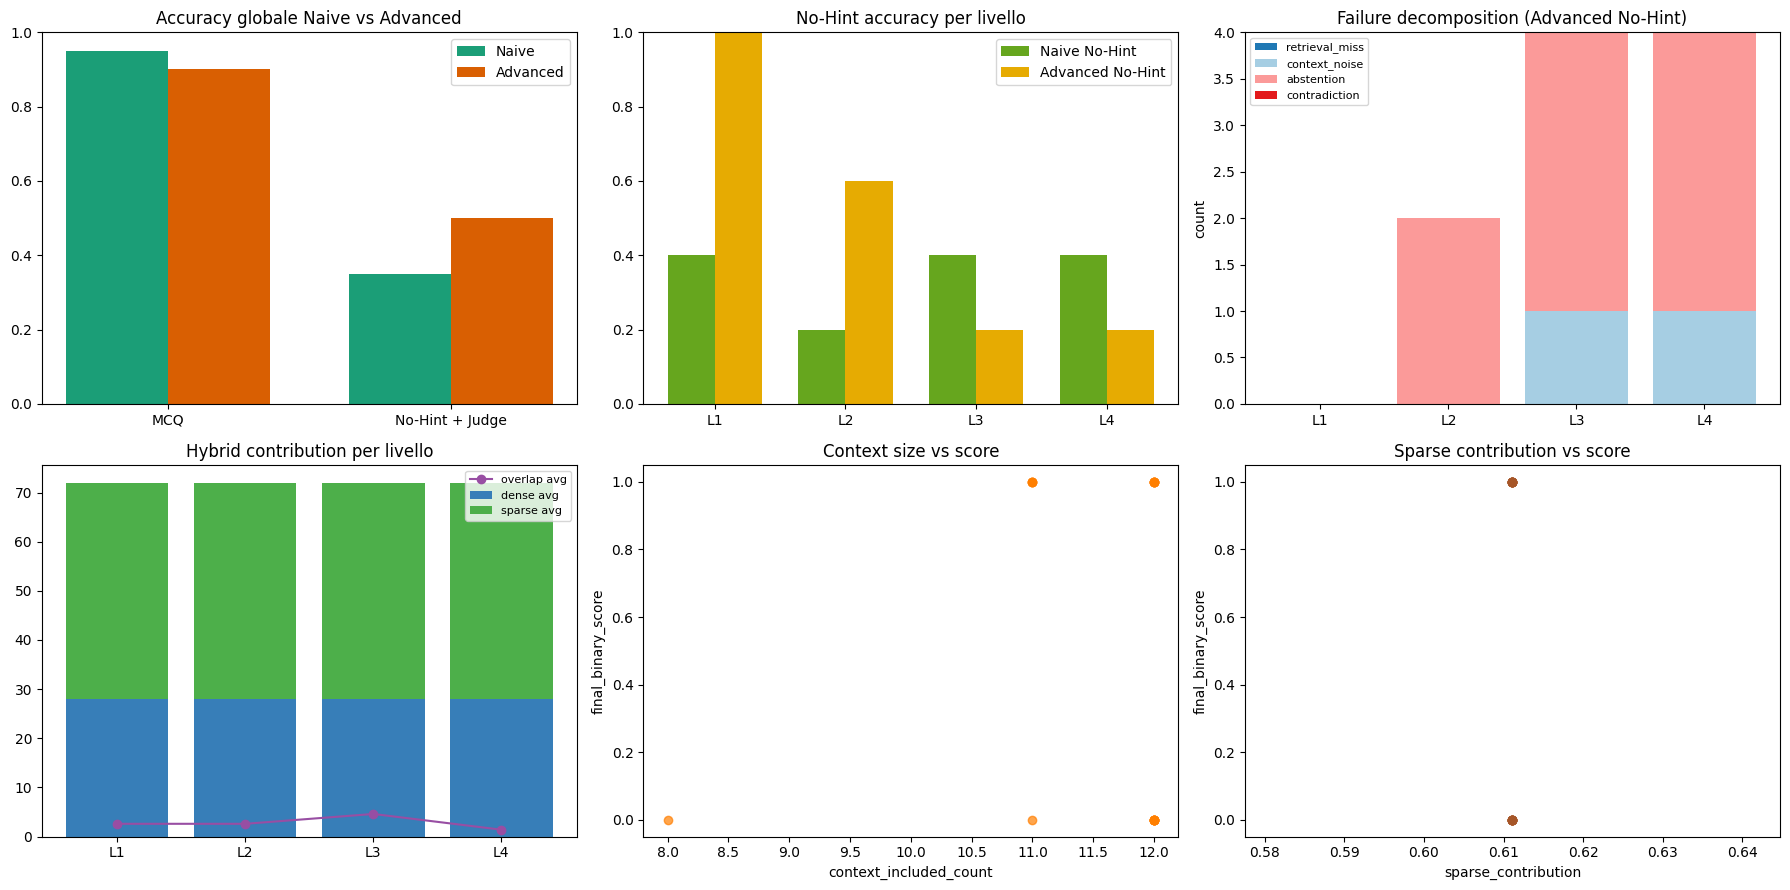

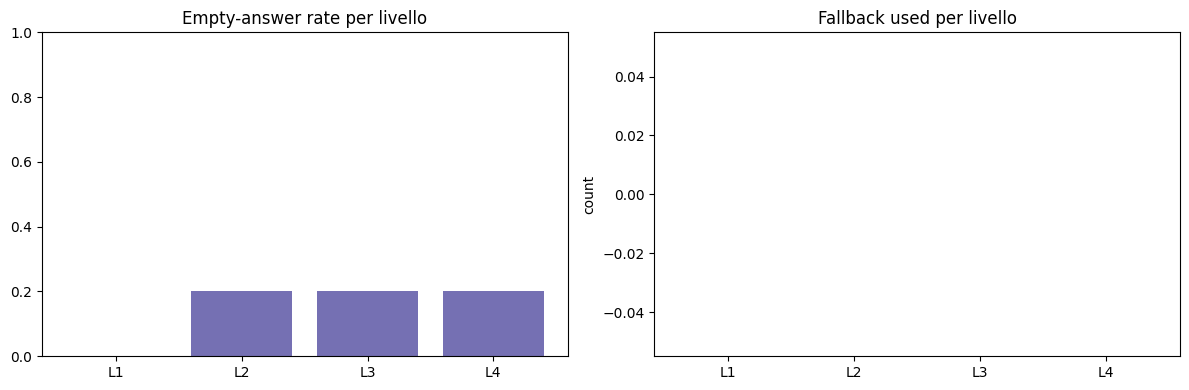

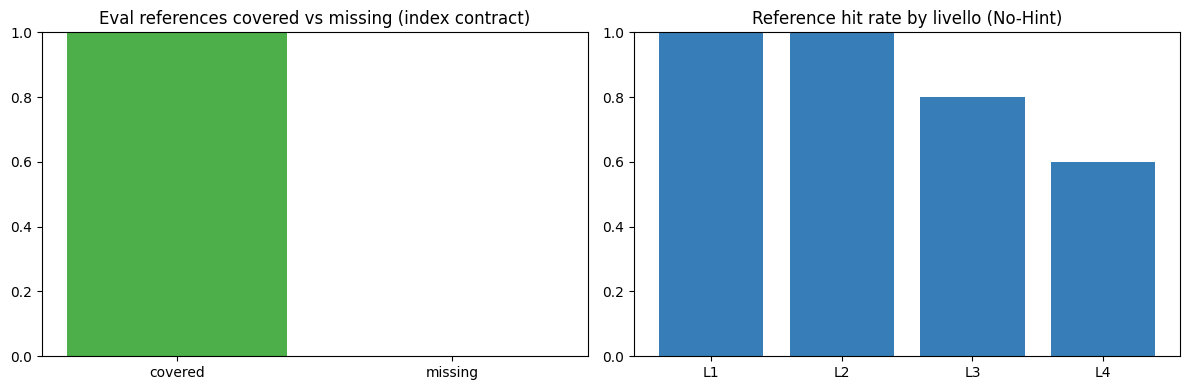

Advanced diagnostics: {
  "mcq_pipeline_error_rows": 5,
  "no_hint_pipeline_error_rows": 3,
  "no_hint_empty_detected_count": 3,
  "no_hint_fallback_used_count": 0,
  "no_hint_empty_by_level": {
    "L1": {
      "processed": 5,
      "empty_detected": 0,
      "fallback_used": 0,
      "empty_rate": 0.0
    },
    "L2": {
      "processed": 5,
      "empty_detected": 1,
      "fallback_used": 0,
      "empty_rate": 0.2
    },
    "L3": {
      "processed": 5,
      "empty_detected": 1,
      "fallback_used": 0,
      "empty_rate": 0.2
    },
    "L4": {
      "processed": 5,
      "empty_detected": 1,
      "fallback_used": 0,
      "empty_rate": 0.2
    }
  },
  "no_hint_failure_breakdown": {
    "abstention": 8,
    "context_noise": 2
  },
  "no_hint_failure_by_level": {
    "L3": {
      "abstention": 3,
      "context_noise": 1
    },
    "L4": {
      "abstention": 3,
      "context_noise": 1
    },
    "L2": {
      "abstention": 2
    }
  },
  "no_hint_retrieval_mode_counts": {

,qid,level,predicted_answer,rag_answer_source,rag_was_empty_before_guard,retrieved_count,final_binary_score,failure_category,judge_result.justification
0,3,L3,Il contesto fornito non contiene la disposizio...,retry,True,21,0,abstention,La risposta del modello non fornisce alcuna in...
2,6,L2,Il documento citato introduce disposizioni in ...,retry,True,19,0,abstention,La risposta del modello non identifica né para...
4,8,L4,Con le informazioni disponibili non è possibil...,retry,True,14,0,abstention,La risposta del modello afferma di non poter i...
9,19,L3,Il contesto fornito non contiene disposizioni ...,model,False,26,0,abstention,The model's response does not provide an answe...
1,4,L4,Il contesto fornito non elenca le istituzioni ...,model,False,23,0,abstention,La risposta del modello non fornisce alcuna de...
8,16,L4,Il contesto fornito non contiene indicazioni e...,model,False,23,0,abstention,The model's response states that the provided ...
6,12,L4,Sì. La normativa regionale prevede che i Comun...,model,False,22,0,context_noise,The model answer states that municipalities ca...
7,14,L2,Non è possibile determinare quale delle produz...,model,False,22,0,abstention,La risposta del modello afferma di non poter d...
3,7,L3,Il provvedimento regionale (vda:lr:2024-10-07:...,model,False,21,0,abstention,The model answer states that the amount cannot...
5,11,L3,"Sì, l'accordo di programma può prevedere la pa...",model,False,18,0,context_noise,The official answer (option D) states that pri...


In [11]:
mcq_results = benchmark_payload['mcq_results']
no_hint_results = benchmark_payload['no_hint_results']

adv_mcq_summary = benchmark_payload['mcq_summary']
adv_no_hint_summary = benchmark_payload['no_hint_summary']
naive_mcq_summary = naive_benchmark_payload['mcq_summary']
naive_no_hint_summary = naive_benchmark_payload['no_hint_summary']

all_levels = sorted(
    set(adv_no_hint_summary['by_level'].keys()) | set(naive_no_hint_summary['by_level'].keys()),
    key=level_sort_key,
)

# 1) Accuracy globale Naive vs Advanced (MCQ e No-Hint)
global_labels = ['MCQ', 'No-Hint + Judge']
naive_global = [
    naive_mcq_summary.get('accuracy') or 0.0,
    naive_no_hint_summary.get('accuracy') or 0.0,
]
adv_global = [
    adv_mcq_summary.get('accuracy') or 0.0,
    adv_no_hint_summary.get('accuracy') or 0.0,
]

# 2) Accuracy per livello No-Hint
naive_level_no_hint = [
    (naive_no_hint_summary['by_level'].get(lvl, {}).get('accuracy') or 0.0)
    for lvl in all_levels
]
adv_level_no_hint = [
    (adv_no_hint_summary['by_level'].get(lvl, {}).get('accuracy') or 0.0)
    for lvl in all_levels
]

adv_no_hint_df = pd.DataFrame(no_hint_results)
if adv_no_hint_df.empty:
    adv_no_hint_df = pd.DataFrame(
        columns=[
            'level', 'failure_category', 'retrieval_mode',
            'dense_retrieved_count', 'sparse_retrieved_count',
            'fusion_overlap_count', 'reference_law_hit',
            'context_included_count', 'final_binary_score',
            'rag_was_empty_before_guard', 'rag_answer_source',
            'top1_law_match', 'context_precision_proxy',
        ]
    )

for col, default in {
    'level': '',
    'failure_category': '',
    'retrieval_mode': 'dense_only',
    'dense_retrieved_count': 0,
    'sparse_retrieved_count': 0,
    'fusion_overlap_count': 0,
    'context_included_count': 0,
    'final_binary_score': 0,
    'rag_was_empty_before_guard': False,
    'rag_answer_source': '',
    'top1_law_match': None,
    'context_precision_proxy': None,
}.items():
    if col not in adv_no_hint_df.columns:
        adv_no_hint_df[col] = default

adv_no_hint_df['level'] = adv_no_hint_df['level'].astype(str)
adv_no_hint_df['sparse_contribution'] = (
    adv_no_hint_df['sparse_retrieved_count'].astype(float)
    / (
        adv_no_hint_df['dense_retrieved_count'].astype(float)
        + adv_no_hint_df['sparse_retrieved_count'].astype(float)
        + 1e-9
    )
)

# 3) Failure decomposition stacked bar (Advanced, no-hint)
failure_categories = ['retrieval_miss', 'context_noise', 'abstention', 'contradiction']
failure_by_level = {lvl: {cat: 0 for cat in failure_categories} for lvl in all_levels}
for _, row in adv_no_hint_df.iterrows():
    lvl = str(row.get('level') or '')
    cat = str(row.get('failure_category') or '')
    if lvl in failure_by_level and cat in failure_categories:
        failure_by_level[lvl][cat] += 1

# 4) Hybrid diagnostics per livello
hybrid_by_level = []
for lvl in all_levels:
    subset = adv_no_hint_df[adv_no_hint_df['level'] == lvl]
    if subset.empty:
        hybrid_by_level.append({'level': lvl, 'dense': 0.0, 'sparse': 0.0, 'overlap': 0.0, 'ref_hit_rate': 0.0})
        continue
    ref_known = subset['reference_law_hit'].dropna()
    ref_hit_rate = float(ref_known.astype(bool).mean()) if not ref_known.empty else 0.0
    hybrid_by_level.append({
        'level': lvl,
        'dense': float(subset['dense_retrieved_count'].mean()),
        'sparse': float(subset['sparse_retrieved_count'].mean()),
        'overlap': float(subset['fusion_overlap_count'].mean()),
        'ref_hit_rate': ref_hit_rate,
    })
hybrid_df = pd.DataFrame(hybrid_by_level)

# 5) Empty/fallback diagnostics
empty_rate_by_level = []
fallback_count_by_level = []
for lvl in all_levels:
    subset = adv_no_hint_df[adv_no_hint_df['level'] == lvl]
    if subset.empty:
        empty_rate_by_level.append(0.0)
        fallback_count_by_level.append(0)
        continue
    empty_rate_by_level.append(float(subset['rag_was_empty_before_guard'].astype(bool).mean()))
    fallback_count_by_level.append(int((subset['rag_answer_source'].astype(str).str.lower() == 'fallback').sum()))

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

xg = list(range(len(global_labels)))
width = 0.36
axes[0, 0].bar([i - width / 2 for i in xg], naive_global, width, label='Naive', color='#1b9e77')
axes[0, 0].bar([i + width / 2 for i in xg], adv_global, width, label='Advanced', color='#d95f02')
axes[0, 0].set_xticks(xg, global_labels)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title('Accuracy globale Naive vs Advanced')
axes[0, 0].legend()

xl = list(range(len(all_levels)))
if all_levels:
    axes[0, 1].bar([i - width / 2 for i in xl], naive_level_no_hint, width, label='Naive No-Hint', color='#66a61e')
    axes[0, 1].bar([i + width / 2 for i in xl], adv_level_no_hint, width, label='Advanced No-Hint', color='#e6ab02')
    axes[0, 1].set_xticks(xl, all_levels)
axes[0, 1].set_ylim(0, 1)
axes[0, 1].set_title('No-Hint accuracy per livello')
axes[0, 1].legend()

if all_levels:
    bottoms = [0] * len(all_levels)
    for cat, color in zip(failure_categories, ['#1f78b4', '#a6cee3', '#fb9a99', '#e31a1c']):
        values = [failure_by_level[lvl][cat] for lvl in all_levels]
        axes[0, 2].bar(all_levels, values, bottom=bottoms, label=cat, color=color)
        bottoms = [b + v for b, v in zip(bottoms, values)]
axes[0, 2].set_title('Failure decomposition (Advanced No-Hint)')
axes[0, 2].set_ylabel('count')
axes[0, 2].legend(fontsize=8)

if not hybrid_df.empty:
    axes[1, 0].bar(hybrid_df['level'], hybrid_df['dense'], label='dense avg', color='#377eb8')
    axes[1, 0].bar(hybrid_df['level'], hybrid_df['sparse'], bottom=hybrid_df['dense'], label='sparse avg', color='#4daf4a')
    axes[1, 0].plot(hybrid_df['level'], hybrid_df['overlap'], marker='o', color='#984ea3', label='overlap avg')
axes[1, 0].set_title('Hybrid contribution per livello')
axes[1, 0].legend(fontsize=8)

axes[1, 1].scatter(
    adv_no_hint_df['context_included_count'].astype(float),
    adv_no_hint_df['final_binary_score'].astype(float),
    alpha=0.7,
    color='#ff7f00',
)
axes[1, 1].set_xlabel('context_included_count')
axes[1, 1].set_ylabel('final_binary_score')
axes[1, 1].set_title('Context size vs score')

axes[1, 2].scatter(
    adv_no_hint_df['sparse_contribution'].astype(float),
    adv_no_hint_df['final_binary_score'].astype(float),
    alpha=0.7,
    color='#a65628',
)
axes[1, 2].set_xlabel('sparse_contribution')
axes[1, 2].set_ylabel('final_binary_score')
axes[1, 2].set_title('Sparse contribution vs score')

plt.tight_layout()
plt.show()

# Grafici diagnostici vuoti/fallback
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
if all_levels:
    ax2[0].bar(all_levels, empty_rate_by_level, color='#7570b3')
    ax2[1].bar(all_levels, fallback_count_by_level, color='#e7298a')
ax2[0].set_ylim(0, 1)
ax2[0].set_title('Empty-answer rate per livello')
ax2[1].set_title('Fallback used per livello')
ax2[1].set_ylabel('count')
plt.tight_layout()
plt.show()

# Coverage chart (index contract)
contract = runtime.index_contract.to_dict()
contract_cov = contract.get('eval_reference_coverage')
missing_sample = contract.get('missing_references_sample') or []

if contract_cov is not None:
    fig3, ax3 = plt.subplots(1, 2, figsize=(12, 4))
    ax3[0].bar(['covered', 'missing'], [contract_cov, max(0.0, 1.0 - float(contract_cov))], color=['#4daf4a', '#e41a1c'])
    ax3[0].set_ylim(0, 1)
    ax3[0].set_title('Eval references covered vs missing (index contract)')

    ref_by_level = (benchmark_payload.get('diagnostics') or {}).get('no_hint_reference_hit_rate_by_level') or {}
    levels_ref = sorted(ref_by_level.keys(), key=level_sort_key)
    vals_ref = [float(ref_by_level.get(lvl) or 0.0) for lvl in levels_ref]
    if levels_ref:
        ax3[1].bar(levels_ref, vals_ref, color='#377eb8')
    ax3[1].set_ylim(0, 1)
    ax3[1].set_title('Reference hit rate by livello (No-Hint)')
    plt.tight_layout()
    plt.show()

print('Advanced diagnostics:', json.dumps(benchmark_payload.get('diagnostics') or {}, ensure_ascii=False, indent=2))
if contract_cov is not None:
    print(f"Index contract eval_reference_coverage: {contract_cov:.3f}")
if missing_sample:
    print('Missing reference sample (contract):')
    for item in missing_sample[:10]:
        print('-', item)

# Tabella top casi scarsi
bad_rows = []
for row in no_hint_results:
    if row.get('error') or row.get('final_binary_score') == 0:
        judge_payload = row.get('judge_result') or {}
        bad_rows.append(
            {
                'qid': row.get('qid'),
                'level': row.get('level'),
                'predicted_answer': row.get('predicted_answer'),
                'rag_answer_source': row.get('rag_answer_source'),
                'rag_was_empty_before_guard': row.get('rag_was_empty_before_guard'),
                'retrieved_count': row.get('retrieved_count'),
                'final_binary_score': row.get('final_binary_score'),
                'failure_category': row.get('failure_category'),
                'judge_result.justification': judge_payload.get('justification'),
            }
        )

top_bad_df = pd.DataFrame(bad_rows)
if top_bad_df.empty:
    print('Nessun caso scarso da mostrare.')
else:
    top_bad_df = top_bad_df.sort_values(
        by=['final_binary_score', 'rag_was_empty_before_guard', 'retrieved_count'],
        ascending=[True, False, False],
    )
    display(top_bad_df.head(20))



## 12) Cleanup risorse


In [12]:
runtime.close()
if 'naive_runtime' in globals() and naive_runtime is not None:
    naive_runtime.close()
print('Runtime chiuso (advanced + naive).')


Runtime chiuso (advanced + naive).
